In [1]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris, load_wine
import warnings
import platform

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
df_c = pd.read_csv("../data/olist_customers_dataset.csv")
df_g = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_oi = pd.read_csv("../data/olist_order_items_dataset.csv")
df_op = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_or = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_o = pd.read_csv("../data/olist_orders_dataset.csv")
df_p = pd.read_csv("../data/olist_products_dataset.csv")
df_s = pd.read_csv("../data/olist_sellers_dataset.csv")

---

In [3]:
# 날짜형 변환
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    df_o[col] = pd.to_datetime(df_o[col], errors='coerce')

# 배송일수(구매→실배송)
df_o['delivery_days'] = (df_o['order_delivered_customer_date'] - df_o['order_purchase_timestamp']).dt.days

# 배송 지연 여부(실배송 > 예상배송)
df_o['is_delayed'] = df_o['order_delivered_customer_date'] > df_o['order_estimated_delivery_date']

In [5]:
order_review = (
    df_o[['order_id','delivery_days','is_delayed']]
    .merge(df_or[['order_id','review_score']], on='order_id', how='inner')
)

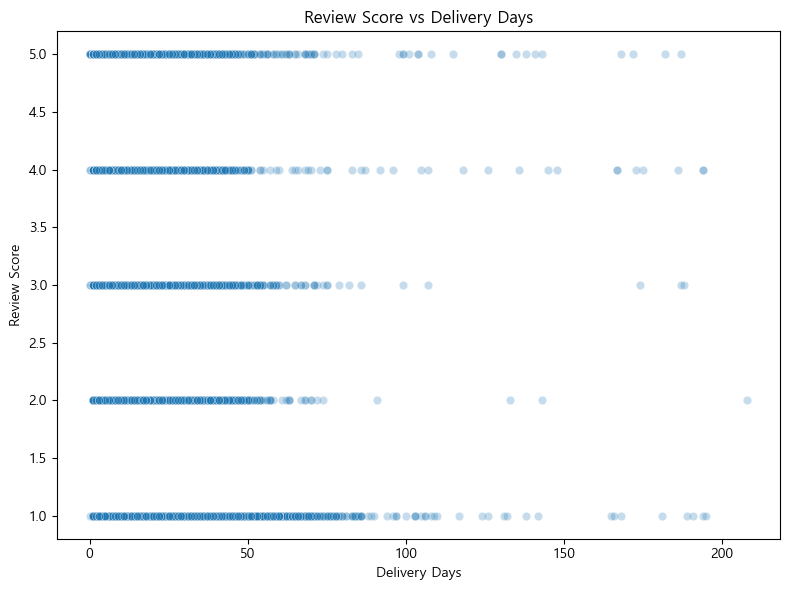

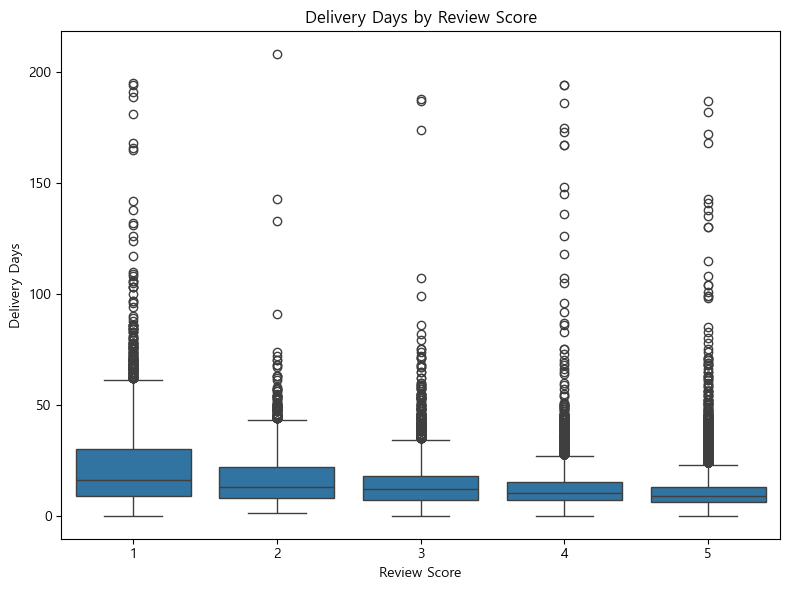

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=order_review, x='delivery_days', y='review_score', alpha=0.25)
plt.title("Review Score vs Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(data=order_review, x='review_score', y='delivery_days')
plt.title("Delivery Days by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")
plt.tight_layout()
plt.show()

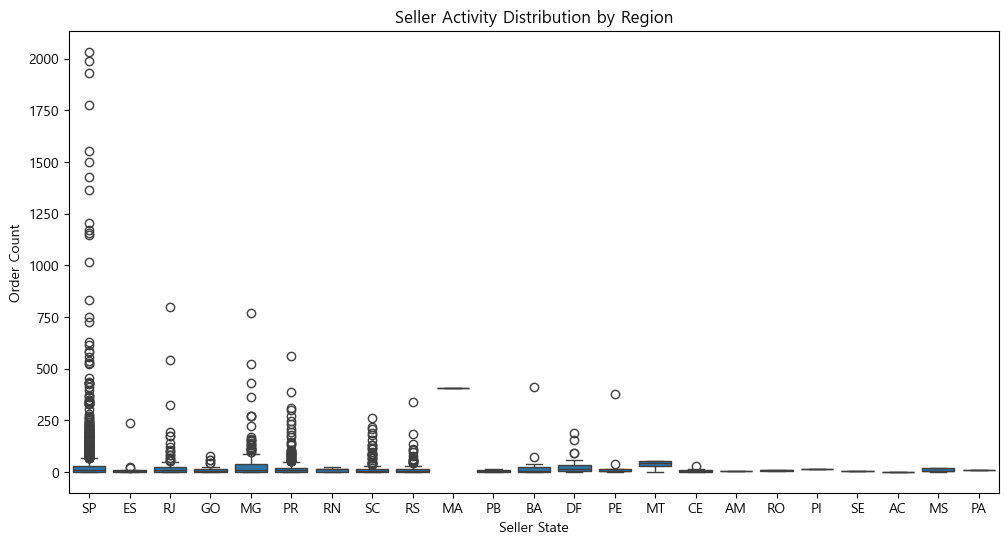

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='seller_state',
    y='order_count',
    data=seller_activity
)

plt.title("Seller Activity Distribution by Region")
plt.xlabel("Seller State")
plt.ylabel("Order Count")

plt.show()

            count   mean  median
is_delayed                      
False       91523  4.214     5.0
True         7701  2.567     2.0


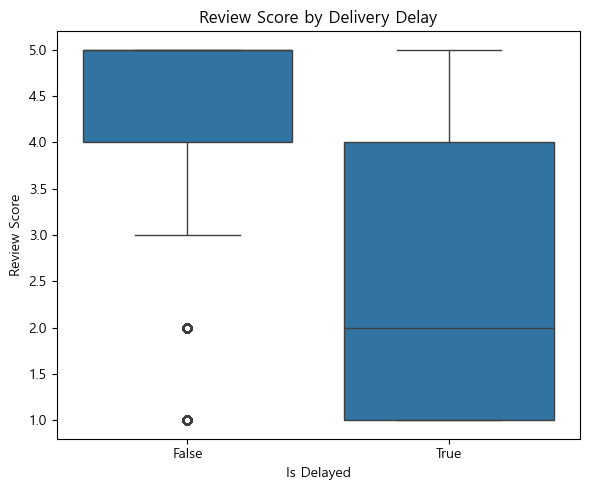

In [7]:
delay_summary = order_review.groupby('is_delayed')['review_score'].agg(['count','mean','median']).round(3)
print(delay_summary)

plt.figure(figsize=(6,5))
sns.boxplot(data=order_review, x='is_delayed', y='review_score')
plt.title("Review Score by Delivery Delay")
plt.xlabel("Is Delayed")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

---

In [8]:
review_region = (
    df_o[['order_id','customer_id']]
    .merge(df_or[['order_id','review_score']], on='order_id', how='inner')
    .merge(df_c[['customer_id','customer_state']], on='customer_id', how='left')
)

review_region = review_region.dropna(subset=['customer_state','review_score'])

In [9]:
state_review = (
    review_region.groupby('customer_state')['review_score']
    .agg(cnt='count', avg='mean')
    .sort_values('avg', ascending=False)
)

print("\n[Top 10 states by avg review]")
print(state_review.head(10).round(3))

print("\n[Bottom 10 states by avg review]")
print(state_review.tail(10).round(3))


[Top 10 states by avg review]
                  cnt    avg
customer_state              
AP                 67  4.194
AM                147  4.184
PR               5038  4.180
SP              41690  4.174
MG              11625  4.136
RS               5483  4.133
MS                724  4.119
RN                482  4.106
MT                903  4.103
TO                279  4.097

[Bottom 10 states by avg review]
                  cnt    avg
customer_state              
PE               1646  4.012
PI                491  3.921
RJ              12765  3.875
BA               3357  3.861
CE               1329  3.851
PA                968  3.849
SE                349  3.808
MA                746  3.764
AL                414  3.751
RR                 46  3.609


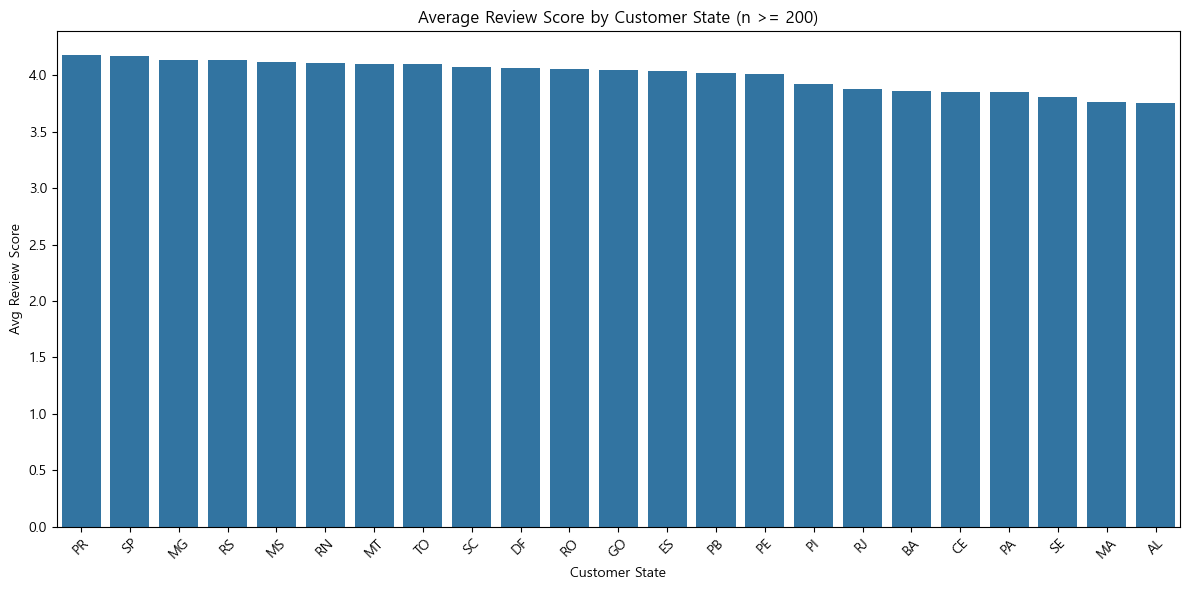

In [10]:
min_n = 200  # 표본 200개 이상인 주만
state_review_f = state_review[state_review['cnt'] >= min_n].sort_values('avg', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=state_review_f.index, y=state_review_f['avg'])
plt.title(f"Average Review Score by Customer State (n >= {min_n})")
plt.xlabel("Customer State")
plt.ylabel("Avg Review Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

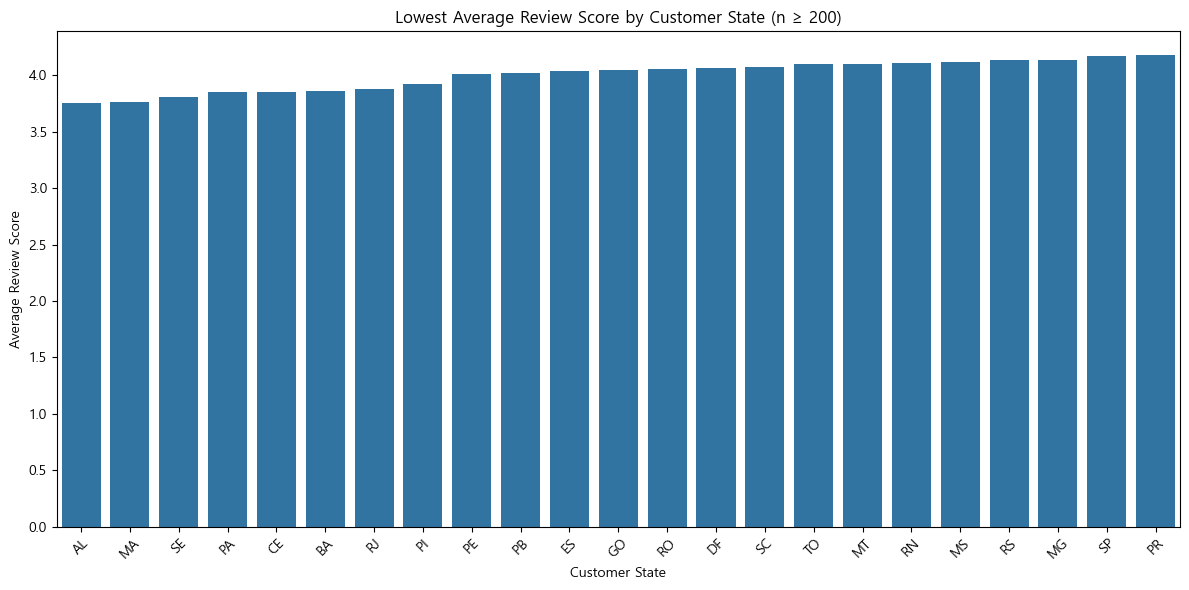

In [18]:
state_review_low = state_review[state_review['cnt'] >= min_n] \
                        .sort_values('avg', ascending=True)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_review_low.index,
    y=state_review_low['avg']
)

plt.title(f"Lowest Average Review Score by Customer State (n ≥ {min_n})")
plt.xlabel("Customer State")
plt.ylabel("Average Review Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

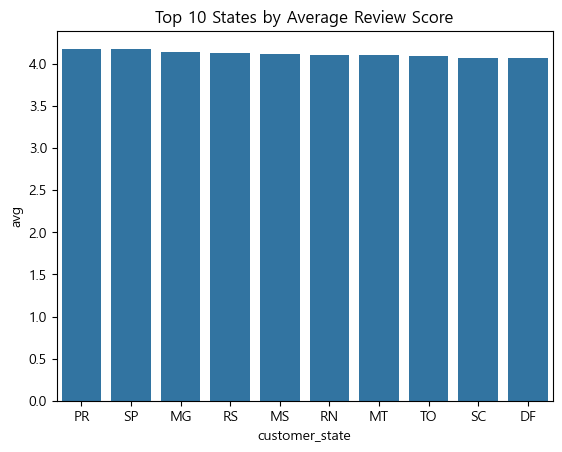

In [16]:
top10 = state_review_f.head(10)

sns.barplot(x=top10.index, y=top10['avg'])
plt.title("Top 10 States by Average Review Score")
plt.show()

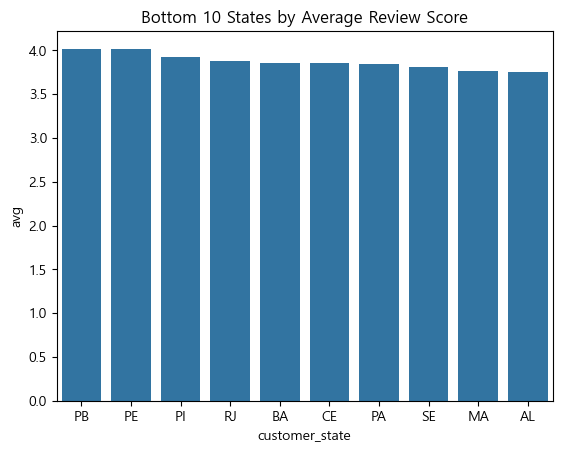

In [17]:
bottom10 = state_review_f.tail(10)

sns.barplot(x=bottom10.index, y=bottom10['avg'])
plt.title("Bottom 10 States by Average Review Score")
plt.show()

---

In [12]:
review_category = (
    df_oi[['order_id','product_id']]
    .merge(df_p[['product_id','product_category_name']], on='product_id', how='left')
    .merge(df_or[['order_id','review_score']], on='order_id', how='inner')
)

review_category = review_category.dropna(subset=['product_category_name','review_score'])

In [13]:
cat_summary = (
    review_category.groupby('product_category_name')['review_score']
    .agg(cnt='count', avg='mean')
    .sort_values('avg', ascending=False)
)

min_n_cat = 300  # 카테고리 표본 최소
cat_summary_f = cat_summary[cat_summary['cnt'] >= min_n_cat]

print("\n[Top 10 categories by avg review]")
print(cat_summary_f.head(10).round(3))

print("\n[Bottom 10 categories by avg review]")
print(cat_summary_f.tail(10).round(3))


[Top 10 categories by avg review]
                         cnt    avg
product_category_name              
livros_interesse_geral   549  4.446
malas_acessorios        1088  4.315
alimentos                495  4.218
papelaria               2507  4.194
pet_shop                1939  4.185
eletrodomesticos         806  4.172
perfumaria              3421  4.162
brinquedos              4091  4.159
instrumentos_musicais    675  4.153
eletroportateis          677  4.149

[Bottom 10 categories by avg review]
                          cnt    avg
product_category_name               
bebes                    3048  4.012
telefonia                4517  3.947
casa_construcao           600  3.940
informatica_acessorios   7849  3.931
moveis_sala               502  3.904
moveis_decoracao         8331  3.903
cama_mesa_banho         11137  3.896
casa_conforto             435  3.830
audio                     361  3.825
moveis_escritorio        1687  3.493


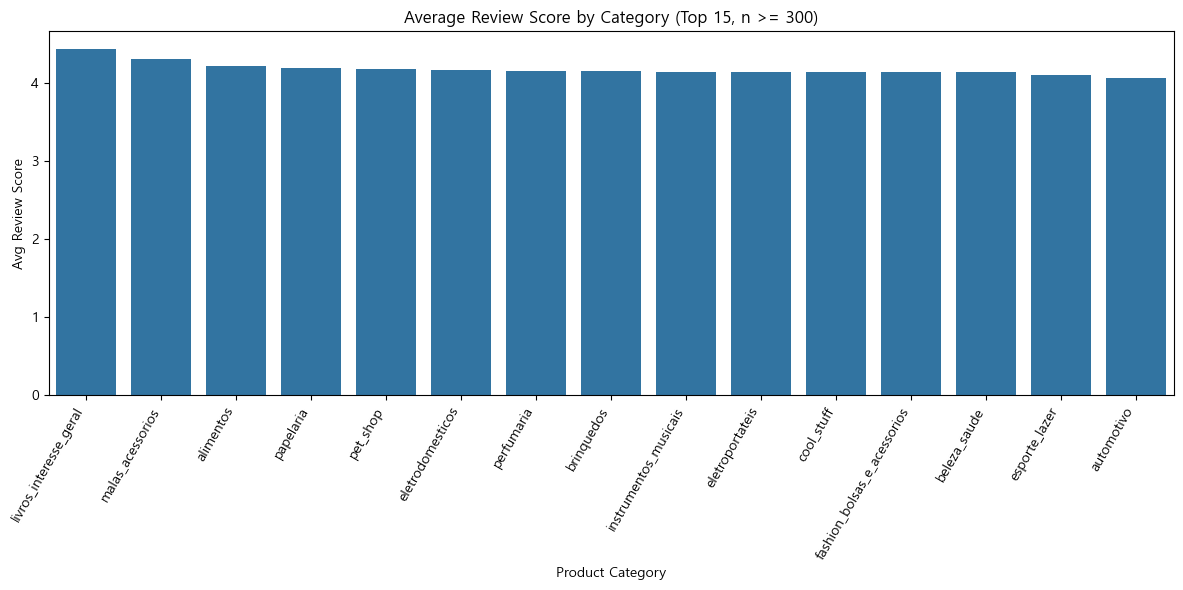

In [14]:
topk = 15
plot_df = cat_summary_f.sort_values('avg', ascending=False).head(topk)

plt.figure(figsize=(12,6))
sns.barplot(x=plot_df.index, y=plot_df['avg'])
plt.title(f"Average Review Score by Category (Top {topk}, n >= {min_n_cat})")
plt.xlabel("Product Category")
plt.ylabel("Avg Review Score")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

In [15]:
review_delivery_region = (
    df_o[['order_id','customer_id','delivery_days']]
    .merge(df_or[['order_id','review_score']], on='order_id', how='inner')
    .merge(df_c[['customer_id','customer_state']], on='customer_id', how='left')
)

tmp = review_delivery_region.dropna(subset=['customer_state','delivery_days','review_score'])
state_combo = (
    tmp.groupby('customer_state')
    .agg(n=('order_id','count'),
         avg_review=('review_score','mean'),
         avg_delivery=('delivery_days','mean'))
)

state_combo = state_combo[state_combo['n'] >= 200].sort_values('avg_review')
print(state_combo.head(10).round(3))

                    n  avg_review  avg_delivery
customer_state                                 
MA                716       3.839        20.936
AL                398       3.842        23.947
SE                334       3.907        20.949
PA                939       3.913        23.187
BA               3246       3.929        18.799
CE               1276       3.938        20.758
RJ              12284       3.963        14.792
PI                472       3.996        19.028
PB                513       4.078        19.750
ES               1978       4.082        15.163


In [19]:
df_or['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64